# EEG Preprocessing

## Overview

You will inspect signal quality, document bad channels, interpolate when positions are known, filter, and re-reference the EEG. The code is a guided skeleton: complete each TODO and justify each decision in your notes.

## Learning objectives

- Identify obvious channel-level problems from traces and spectra.
- Explain interpolation, filtering, and referencing.
- Apply operations to copies so the imported data remain available for comparison.
- Document parameters and save a reproducible preprocessed file.

## Background: Why preprocessing matters

EEG contains brain activity plus drift, line noise, eye movements, muscle activity, movement, and poor electrode contact. Preprocessing changes the data and cannot repair every problem. Choose parameters before looking for the expected condition difference, and document choices that could affect the result.

In [ ]:
# Setup cell: run this as provided.
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd

mne.set_log_level("WARNING")

## Step 1: Load the raw MNE file

Use `mne.io.read_raw_fif` with `preload=True`; later operations need samples in memory. Make a separate copy named `raw_original` that will not be modified. Print the object and confirm that annotations from Notebook 1 are present.

In [48]:
from pathlib import Path
import mne

RAW_PATH = Path("../outputs/raw_eeg.fif")

# TODO: load with preload=True and create an untouched copy.
RAW_PATH = Path("../outputs/raw_eeg.fif")

RAW_PATH = Path("../outputs/raw_eeg.fif")

RAW_PATH = Path("../outputs/raw_eeg.fif")

raw = mne.io.read_raw_fif(RAW_PATH, preload=True)
raw.set_channel_types({
    "X1": "misc",
    "X2": "misc",
    "X3": "misc",
    "A2": "eeg",
    "TRG": "misc",
})
raw_original = raw.copy()

print(raw)
print(f"Duration: {raw.times[-1]:.2f} s")
print(f"Channels: {len(raw.ch_names)}")
print(f"Annotations: {len(raw.annotations)}")
raw_original = raw.copy()



Opening raw data file ..\outputs\raw_eeg.fif...
Isotrak not found
    Range : 0 ... 211647 =      0.000 ...   705.490 secs
Ready.
Reading 0 ... 211647  =      0.000 ...   705.490 secs...
<Raw | raw_eeg.fif, 24 x 211648 (705.5 s), ~38.8 MiB, data loaded>
Duration: 705.49 s
Channels: 24
Annotations: 76


C:\Users\wpafb\AppData\Local\Temp\ipykernel_14916\2651998488.py:14: RuntimeWarning: The unit for channel(s) TRG, X1, X2, X3 has changed from V to NA.
  raw.set_channel_types({


## Step 2: Visually inspect EEG

Plot at least 15 seconds with `raw.plot`. Scroll across the recording and look for flat channels, persistent extreme amplitudes, sudden jumps, and channels unlike their neighbors. Eye blinks usually affect frontal channels and do not automatically make those channels bad.

Then calculate standard deviation and peak-to-peak amplitude for each EEG channel. Sort the table, but do not label a channel bad from one number alone.

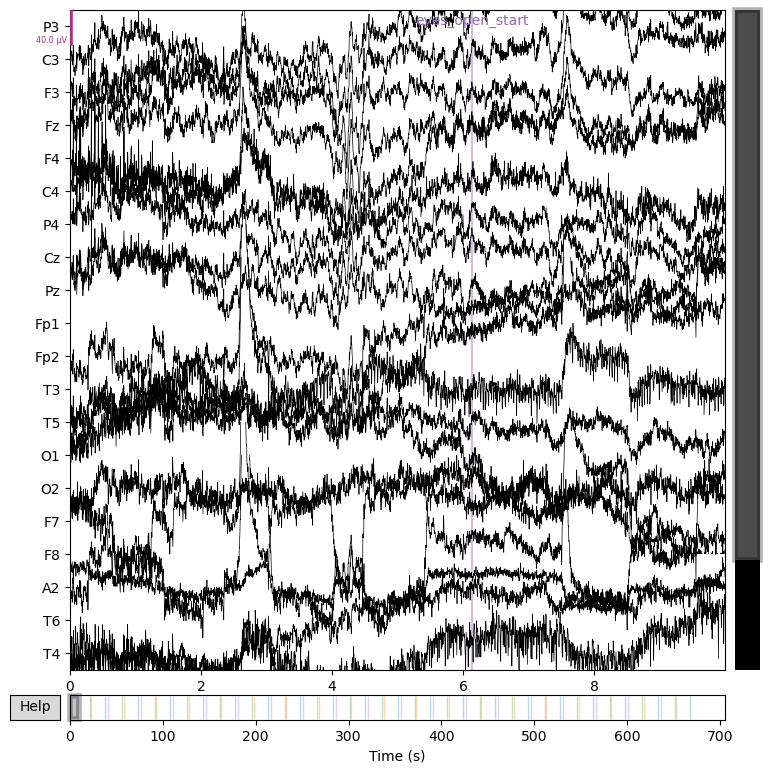

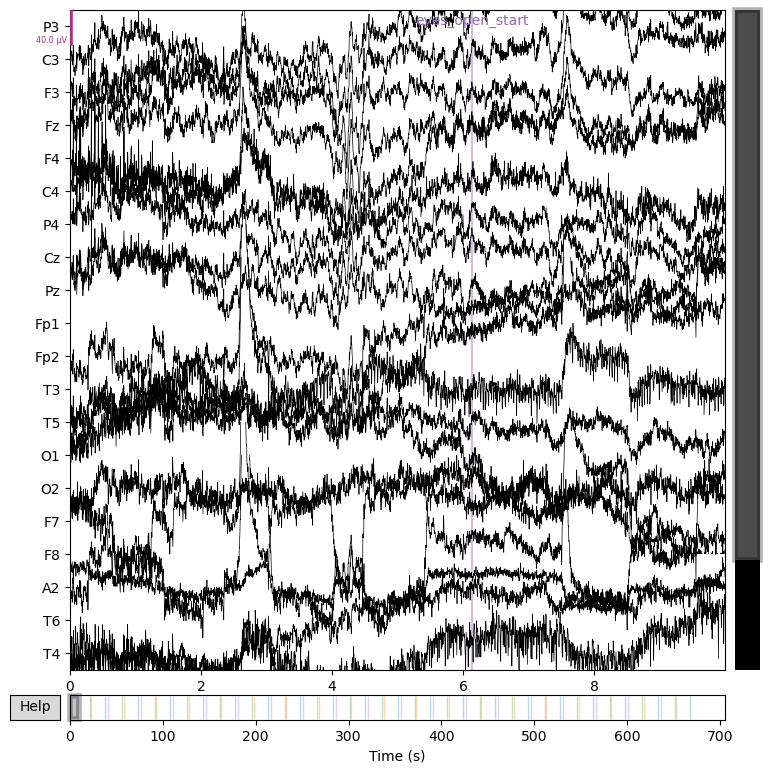

In [49]:
raw.plot()

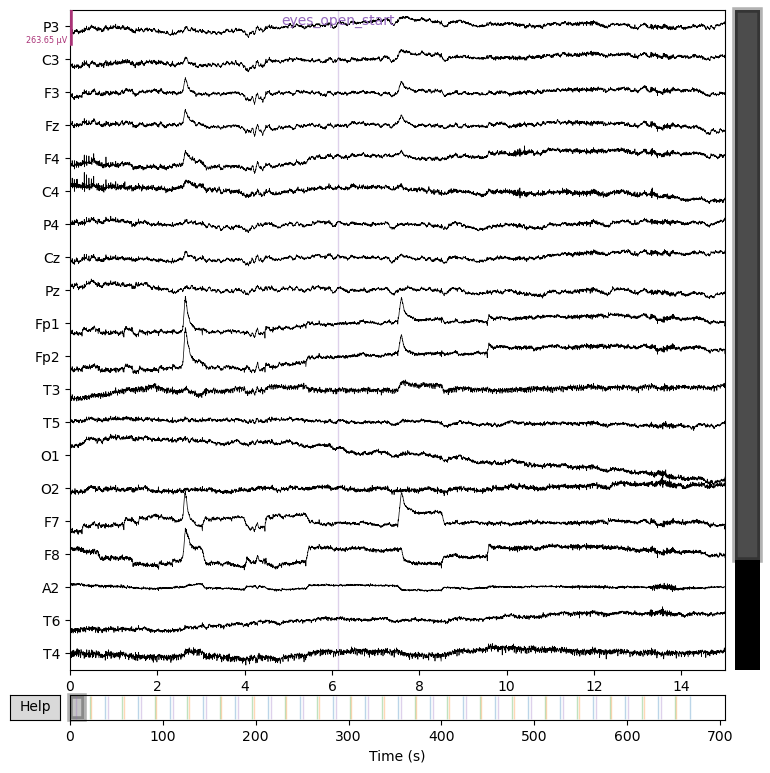

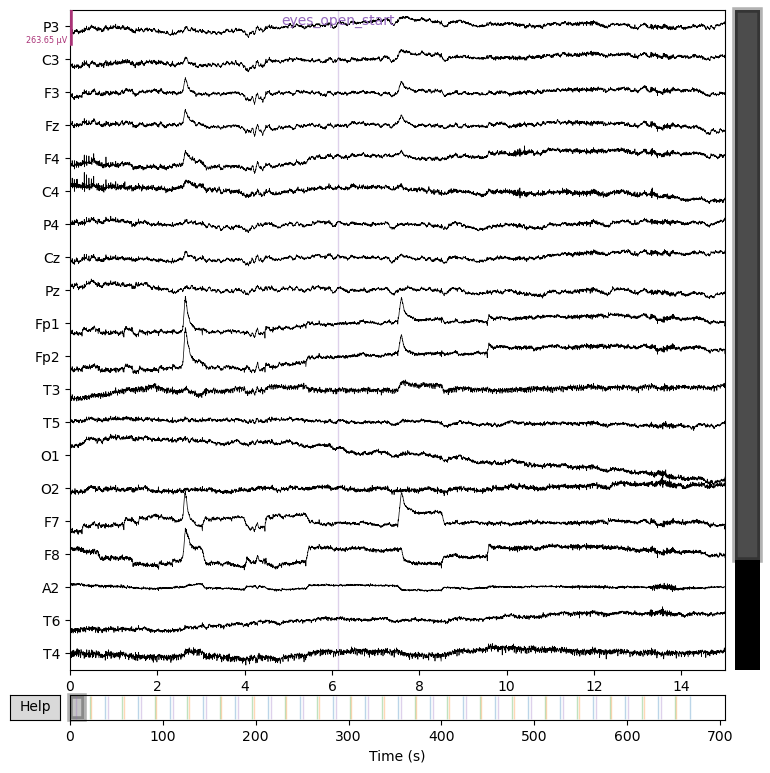

,standard_deviation_uV,peak_to_peak_uV
C4,1385.416549,6862.647133
Fp2,291.021456,4543.582385
Fp1,227.637346,4183.750600
F7,204.426801,4057.593353
F8,186.066914,3459.747240
F4,180.166142,2758.440678
O1,410.895320,2451.175416
T6,196.361230,2386.900422
C3,99.255071,1712.692494
O2,106.895976,1154.041733


<function matplotlib.pyplot.show(close=None, block=None)>

In [51]:
import pandas as pd
import numpy as np

# TODO: inspect the continuous data interactively.
raw.plot(
    duration=15,
    n_channels=min(20, len(raw.ch_names)),
    scalings="auto",
)

# TODO: get EEG data and summarize each channel in microvolts.
eeg_data =  raw.get_data()
# TODO: get EEG data and summarize each channel in microvolts.
eeg_picks = mne.pick_types(raw.info, eeg=True, exclude=[])
eeg_data = raw.get_data(picks=eeg_picks)

# ensure pandas is available in this cell

# TODO: inspect the continuous data interactively.
raw.plot(
    duration=15,
    n_channels=min(20, len(raw.ch_names)),
    scalings="auto",
)

# TODO: get EEG data and summarize each channel in microvolts.
eeg_data = raw.get_data()
# TODO: get EEG data and summarize each channel in microvolts.
eeg_picks = mne.pick_types(raw.info, eeg=True, exclude=[])
eeg_data = raw.get_data(picks=eeg_picks)

quality_table = pd.DataFrame(
    {
        "standard_deviation_uV": np.std(eeg_data, axis=1) * 1e6,
        "peak_to_peak_uV": np.ptp(eeg_data, axis=1) * 1e6,
    },
    index=[raw.ch_names[pick] for pick in eeg_picks],
).sort_values("peak_to_peak_uV", ascending=False)

display(quality_table)

plt.show()

## Step 3: Identify and mark bad channels

A bad channel is unusable for most of the recording. Enter names only after checking traces, spectra, amplitudes, and nearby channels. Add the list to `raw.info['bads']`. Check for spelling errors by comparing with `raw.ch_names`. Record the reason for every choice outside the notebook output.

In [52]:
# STUDENT EDIT: for example ["Fp1", "T8"].
bad_channels = []

# Detect names not present in raw.ch_names and raise a helpful error.
unknown_bads = sorted(set(bad_channels) - set(raw.ch_names))
if unknown_bads:
    raise ValueError(f"Unknown bad-channel names: {unknown_bads}")

# TODO: store the verified list in MNE's bad-channel field.
raw.info["bads"] = bad_channels
print("Marked bad channels:", raw.info["bads"])


Marked bad channels: []


## Step 4: Interpolate bad channels

Interpolation estimates a bad channel from nearby sensors, so correct electrode positions are required. Confirm the cap layout before selecting a montage. `standard_1020` is appropriate only if channel labels and locations actually follow that system. Generic names such as `EEG001` require a recording-specific montage.

Attach the montage with `set_montage`, copy the data, and call `interpolate_bads(reset_bads=True)` only when the list is nonempty. Keep the original list in `bad_channels` for documentation.

In [53]:
# STUDENT EDIT after confirming the cap layout.
MONTAGE_NAME = "standard_1020"

# TODO: create and attach the montage. Decide how missing names should be handled.
montage = mne.channels.make_standard_montage(MONTAGE_NAME)
raw.set_montage(montage, on_missing="warn")

raw_interpolated = raw.copy()
if bad_channels:
    # TODO: interpolate and reset successfully repaired channels to usable.
        raw_interpolated.interpolate_bads(reset_bads=True)

else:
    print("No bad channels selected; interpolation skipped.")

    

No bad channels selected; interpolation skipped.


## Step 5: Bandpass filtering

Create a new copy and use `filter(l_freq=1.0, h_freq=40.0, picks='eeg')`. This suppresses slow drift and activity above the frequency range used here. It does not remove all artifacts, and filtered edges should be treated cautiously.

In [54]:
# TODO: copy the interpolated data and apply a 1–40 Hz EEG filter.
raw_filtered = raw_interpolated.copy()

raw_filtered.filter(
    l_freq=1.0,
    h_freq=40.0,
    picks="eeg",
)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 991 samples (3.303 s)



<Raw | raw_eeg.fif, 24 x 211648 (705.5 s), ~38.8 MiB, data loaded>

## Step 6: Notch filtering

North American line noise is commonly 60 Hz. Because the preceding low-pass is 40 Hz, a 60 Hz notch is generally redundant. This exercise makes that decision explicit. Apply `notch_filter(freqs=[60.0])` to a copy of the filtered data.

**Extension:** If the unfiltered PSD has severe 60 Hz noise, test a pipeline that notches before the 1–40 Hz band-pass and document why.

In [55]:
raw_notched = raw_filtered.copy()

# TODO: apply the 60 Hz notch.
raw_notched.notch_filter(freqs=[60.0], picks="eeg",)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 1981 samples (6.603 s)



<Raw | raw_eeg.fif, 24 x 211648 (705.5 s), ~38.8 MiB, data loaded>

## Step 7: Common average reference

EEG voltages are always measured relative to a reference. Common average reference subtracts the instantaneous mean across usable EEG channels. It is most defensible with broad scalp coverage. Use `set_eeg_reference()` with on another copy to re-reference the EEG data to the average over all available channels.

In [56]:
# TODO: copy the data and apply a common average reference immediately.
raw_preprocessed = raw_notched.copy()
raw_preprocessed.set_eeg_reference(
    ref_channels="average",
    projection=False,
)
raw_preprocessed

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


<Raw | raw_eeg.fif, 24 x 211648 (705.5 s), ~38.8 MiB, data loaded>

## Step 8: Compare before and after preprocessing

Plot the same time window before and after preprocessing. Then compute Welch PSDs with `compute_psd` and plot the mean spectrum before and after. Use the same relevant axis limits when possible. Describe changes near 1 Hz, within alpha (8–12 Hz), near 40 Hz, and near 60 Hz. A smoother plot is not automatically a better biological signal.

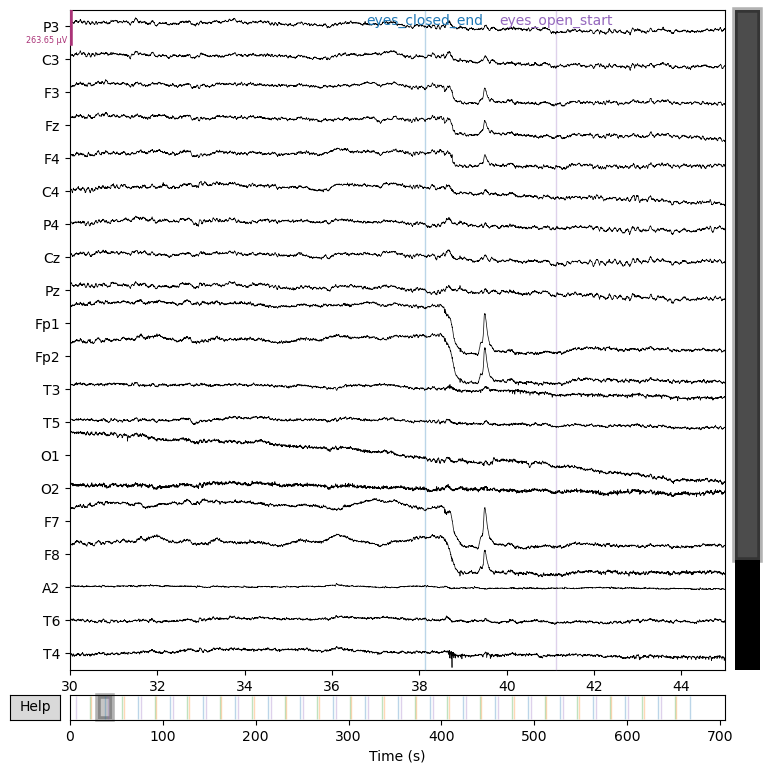

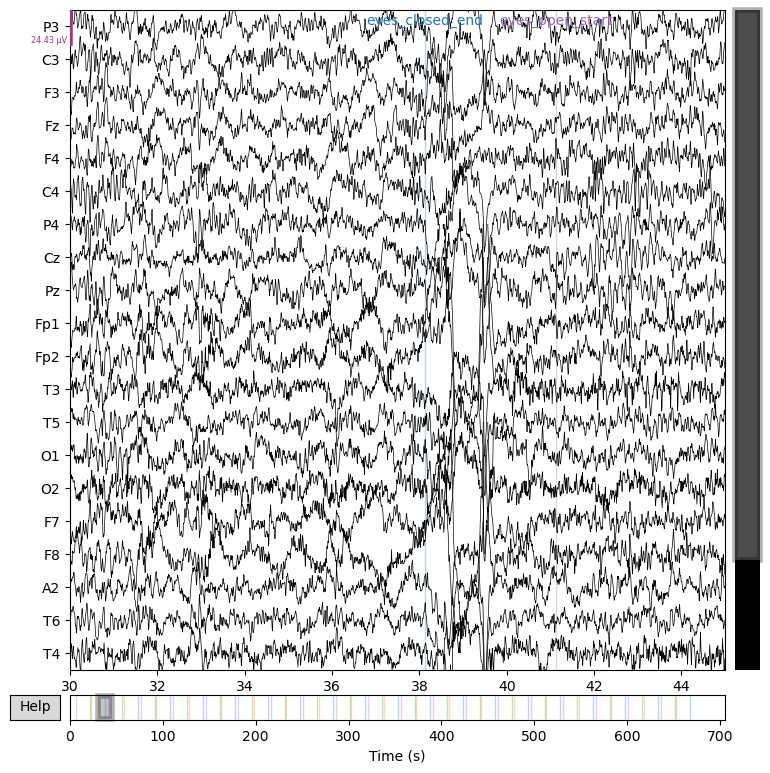

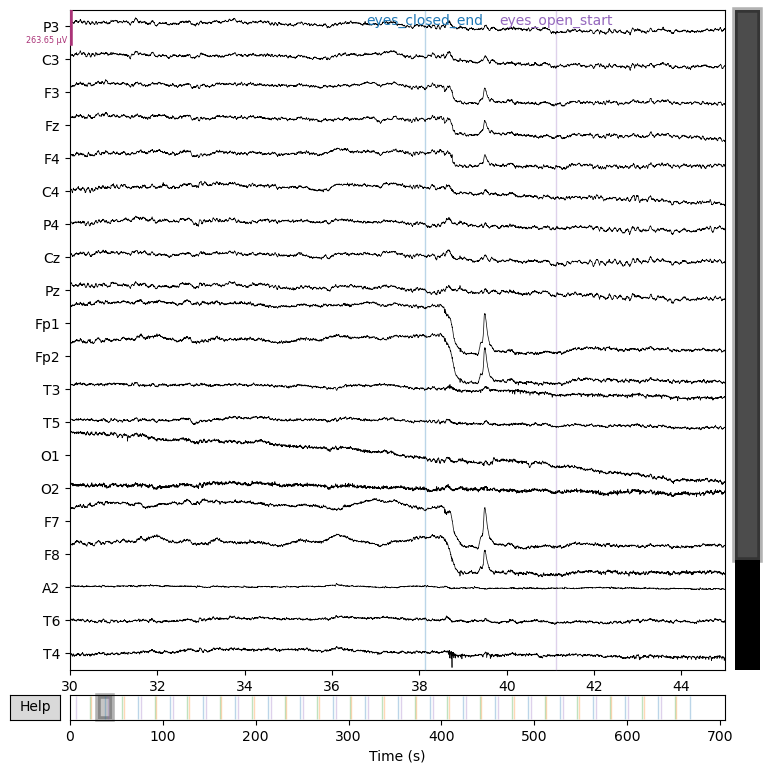

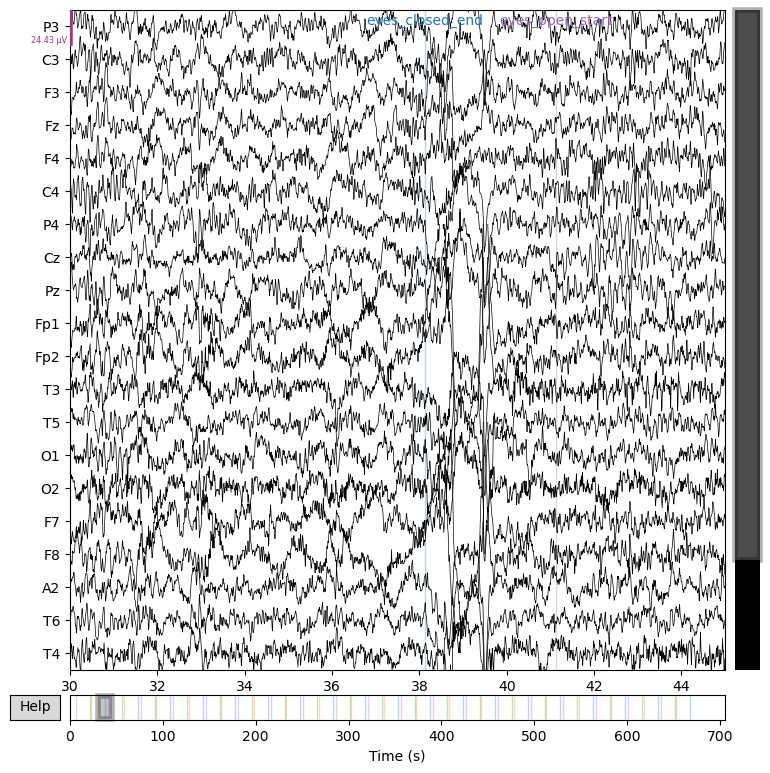

Effective window size : 6.827 (s)
Effective window size : 6.827 (s)


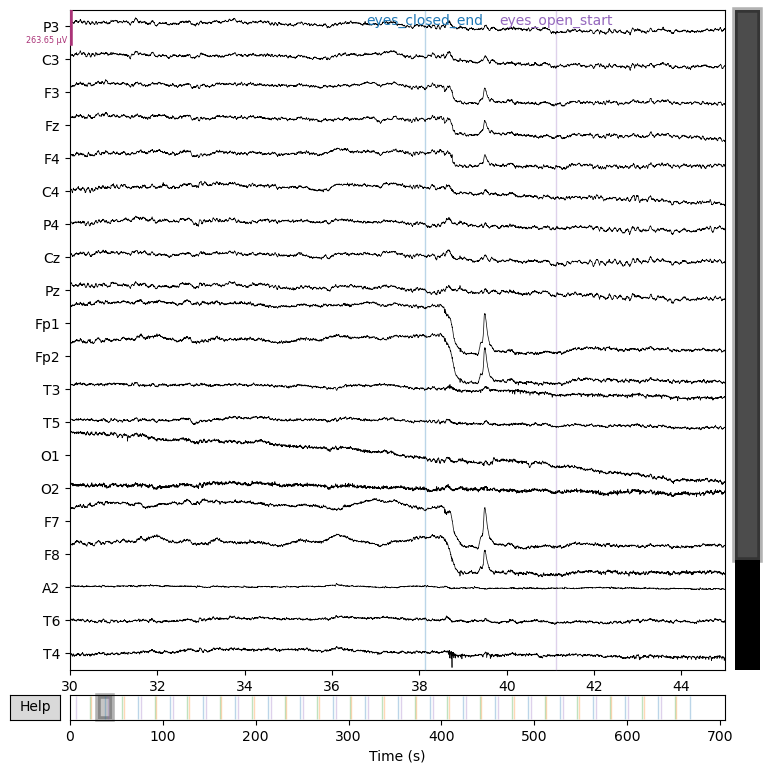

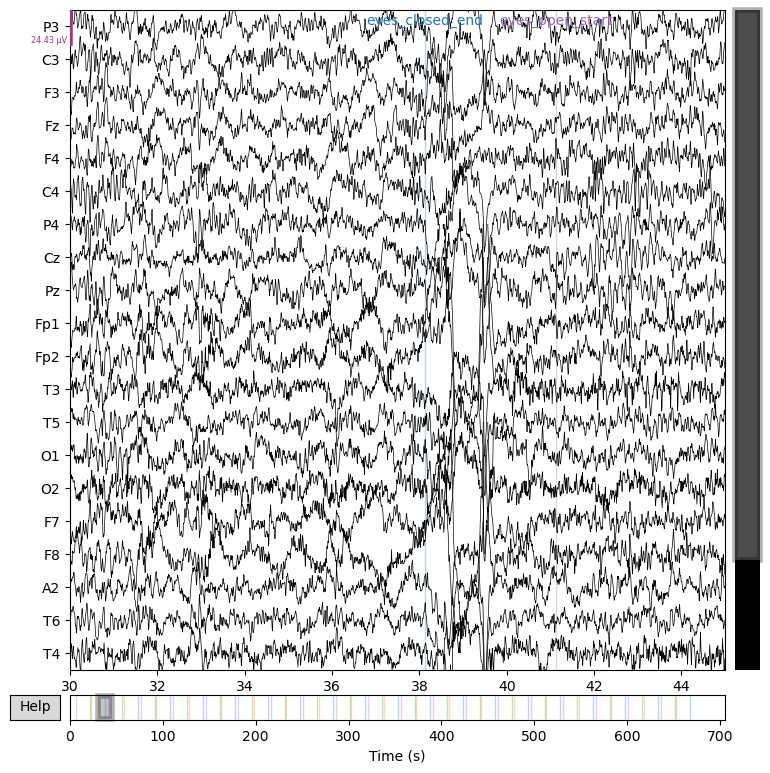

Effective window size : 6.827 (s)
Effective window size : 6.827 (s)
Plotting power spectral density (dB=True).
Plotting power spectral density (dB=True).
Effective window size : 6.827 (s)


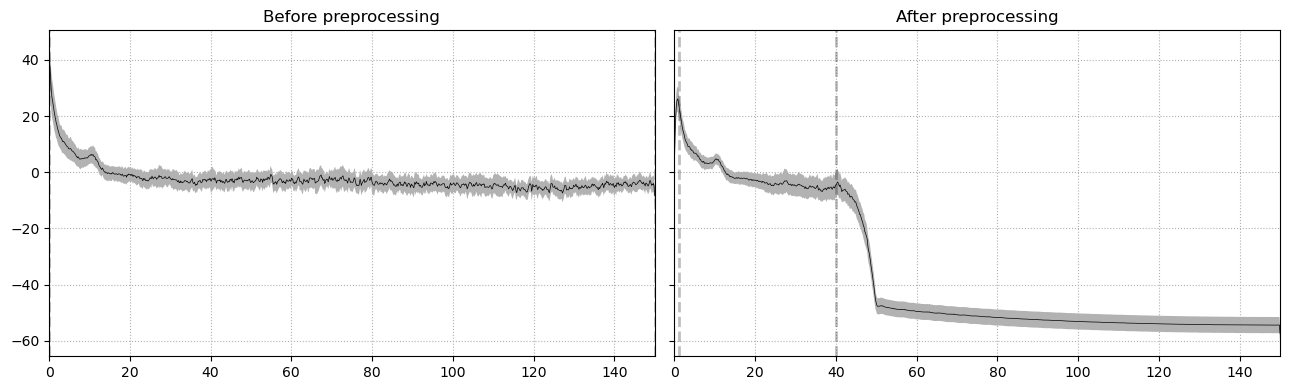

In [57]:
# TODO: plot matching raw time windows before and after.
raw_original.plot(start=30,
    duration=15,
    n_channels=min(20, len(raw_original.ch_names)),
    scalings="auto",)

raw_preprocessed.plot( start=30,
    duration=15,
    n_channels=min(20, len(raw_preprocessed.ch_names)),
    scalings="auto",)

# TODO: compute and plot before/after PSDs.
# TODO: plot matching raw time windows before and after.
raw_original.plot(
    start=30,
    duration=15,
    n_channels=min(20, len(raw_original.ch_names)),
    scalings="auto",
)

raw_preprocessed.plot(
    start=30,
    duration=15,
    n_channels=min(20, len(raw_preprocessed.ch_names)),
    scalings="auto",
)

# TODO: compute and plot before/after PSDs.
psd_before = raw_original.compute_psd(method="welch", picks="eeg")
psd_after = raw_preprocessed.compute_psd(method="welch", picks="eeg")

import matplotlib.pyplot as plt

raw_original.plot(
    start=30,
    duration=15,
    n_channels=min(20, len(raw_original.ch_names)),
    scalings="auto",
)

raw_preprocessed.plot(
    start=30,
    duration=15,
    n_channels=min(20, len(raw_preprocessed.ch_names)),
    scalings="auto",
)

psd_before = raw_original.compute_psd(method="welch", picks="eeg")
psd_after = raw_preprocessed.compute_psd(method="welch", picks="eeg")

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
psd_before.plot(axes=axes[0], average=True, show=False)
psd_after.plot(axes=axes[1], average=True, show=False)
axes[0].set_title("Before preprocessing")
axes[1].set_title("After preprocessing")
plt.tight_layout()
psd_after = raw_preprocessed.compute_psd(method="welch", picks="eeg")
plt.show()

## Step 9: Save preprocessed data

Add a short description containing the original bad-channel list and processing parameters to `raw_preprocessed.info['description']`. Then save to the requested path with `overwrite=True`. In a real project, also keep a structured processing log.

In [ ]:
OUTPUT_PATH = Path("../outputs/raw_preprocessed.fif")
processing_note = (
    f"Original bad channels={bad_channels}; montage={MONTAGE_NAME}; "
    "60 Hz notch; 1–40 Hz band-pass; common average reference."
)

# TODO: document choices, save the file, and print its absolute path.
raw_preprocessed.info["description"] = ...
...

## Student exercises

1. Create a preprocessing log with operation, parameter, reason, and observed effect.
2. Plot one channel over the same 10 seconds before and after filtering.
3. Decide from the unfiltered PSD whether a notch was necessary. Support your answer with a figure.

## Reflection questions

- Were any channels obviously noisy? What independent evidence did you use?
- Why does interpolation require accurate positions?
- What information is removed by a 1–40 Hz filter?
- How could preprocessing choices accidentally favor the expected result?

## Summary

After completing the skeleton, you will have made and documented each preprocessing decision, compared its effects, and saved a traceable preprocessed dataset.